In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [75]:
df = pd.read_csv('Mixx_metrics.csv', encoding='utf-8', delimiter='\t')

In [76]:
df['report_month'] = pd.to_datetime(df['report_month'], format='%d.%m.%Y')
df['ACTIVE_AT_START'] = pd.to_numeric(df['ACTIVE_AT_START'])
df['CHURNED'] = pd.to_numeric(df['CHURNED'])

In [77]:
df.head()

,report_month,REGION,BRANCH,SERVICE,ACTIVE_AT_START,CHURNED
0,2023-11-01,Байкал и Дальний Восток,Биробиджан,Не использовать_MiXX S_03_2023,438,4
1,2023-11-01,Байкал и Дальний Восток,Биробиджан,MiXX Max_09_2024,59,2
2,2023-11-01,Байкал и Дальний Восток,Биробиджан,Не использовать_MiXX Max_03_2023,32,0
3,2023-11-01,Байкал и Дальний Восток,Биробиджан,Не использовать_MiXX L_03_2023,7,0
4,2023-11-01,Байкал и Дальний Восток,Биробиджан,MiXX L_09_2024,19,0


In [79]:
all_report_months = r = df.groupby(['report_month'])[['ACTIVE_AT_START','CHURNED']].agg({
    'ACTIVE_AT_START' : sum,
    'CHURNED' : sum
})

In [82]:
all_report_months['prcnt'] = np.round(all_report_months['CHURNED'] / all_report_months['ACTIVE_AT_START'] * 100, 2)

In [87]:
all_report_months

,ACTIVE_AT_START,CHURNED,prcnt
report_month,,,
2023-11-01,2201701,332590,15.11
2023-12-01,2990254,450070,15.05
2024-01-01,3631631,1150293,31.67
2024-02-01,3196271,867627,27.14
2024-03-01,3027067,682211,22.54
2024-04-01,3074951,655664,21.32
2024-05-01,3120138,576005,18.46
2024-06-01,3140914,622854,19.83
2024-07-01,3155230,572504,18.14


<Axes: xlabel='report_month', ylabel='prcnt'>

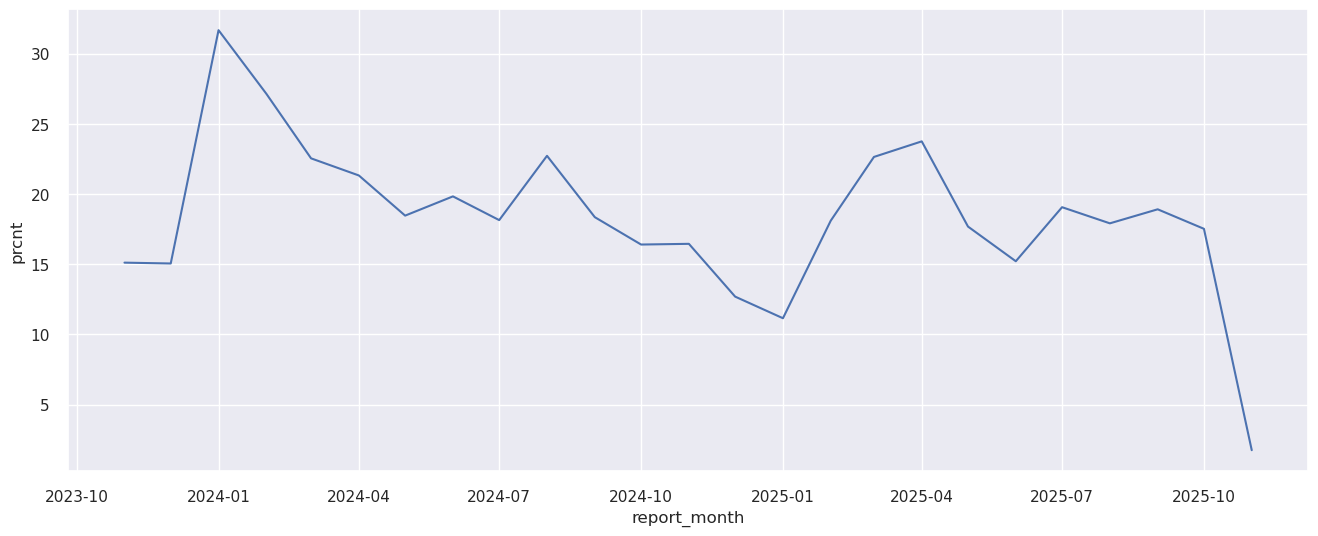

In [134]:
sns.set(rc={'figure.figsize':(16, 6)})
sns.lineplot(all_report_months['prcnt'])

In [126]:
r = df.groupby(['report_month', 'SERVICE'])[['ACTIVE_AT_START','CHURNED']].agg({
    'ACTIVE_AT_START' : sum,
    'CHURNED' : sum
}).reset_index()

In [161]:
rep = r.loc[r.report_month == '2024-10-01'].copy()
rep['prcnt'] = np.round(rep['CHURNED'] / rep['ACTIVE_AT_START'].sum() * 100, 2)

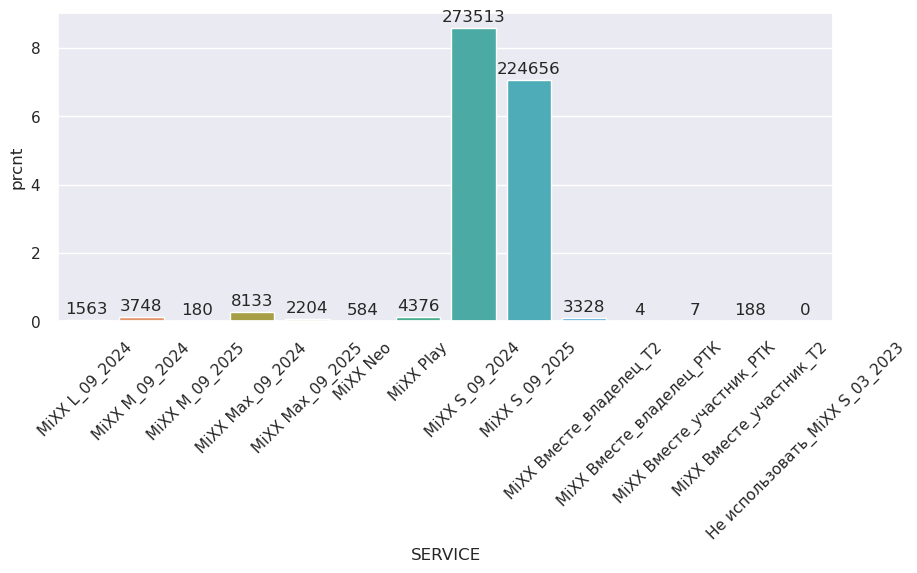

In [162]:
sns.set(rc={'figure.figsize':(10,4)})
ax = sns.barplot(data=rep, x='SERVICE', y='prcnt')
plt.gca().tick_params(axis='x', rotation=45)

# Добавляем подписи количества churned на столбиках
for i, p in enumerate(ax.patches):
    height = p.get_height()
    service = rep['SERVICE'].iloc[i]
    churned_value = rep[rep['SERVICE'] == service]['CHURNED'].values[0]
    ax.text(p.get_x() + p.get_width()/2., height + 0.1,
            f'{churned_value}', ha='center', va='bottom')

plt.show()